# 02 - Dataset Split
Splits the standardized images into train / val / test sets using the folder structure as class labels.

**Input structure (from notebook 01):**
```
data/raw/
    ├── id_new/    → id_new_1.jpg, id_new_2.jpg ...   (label: 0)
    ├── id_old/    → id_old_1.jpg, id_old_2.jpg ...   (label: 1)
    ├── passport/  → passport_1.jpg, passport_2.jpg ...   (label: 2)
    └── unknown/   → unknown_1.jpg, unknown_2.jpg ...   (label: 3)
```

**Output structure:**
```
data/
    ├── train/   (70%) ← model learns from this
        ├── id_new/
        ├── id_old/
        ├── passport/
        └── unknown/
    ├── val/     (15%) ← tune hyperparams, early stopping
        ├── id_new/
        ├── id_old/
        ├── passport/
        └── unknown/
    └── test/    (15%) ← final metrics only, never touched during training
        ├── id_new/
        ├── id_old/
        ├── passport/
        └── unknown/
```

In [84]:
import shutil
import sys
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split

In [85]:
GLOBAL_PATH = str(Path.cwd().parent.parent / "global")
if GLOBAL_PATH not in sys.path:
    sys.path.append(GLOBAL_PATH)
%reload_ext autoreload
%autoreload 2
import config

In [86]:
print(f"Source : {config.RAW_DIR}")
print(f"Train  : {config.TRAIN_DIR}")
print(f"Val    : {config.VAL_DIR}")
print(f"Test   : {config.TEST_DIR}")

Source : D:\Aprender\Projects\ecuadorian-id-classifier\data\raw
Train  : D:\Aprender\Projects\ecuadorian-id-classifier\data\train
Val    : D:\Aprender\Projects\ecuadorian-id-classifier\data\val
Test   : D:\Aprender\Projects\ecuadorian-id-classifier\data\test


In [87]:
all_images = []   # list of Path objects
all_labels = []   # list of ints (0, 1, 2, 3)

for class_name, label in config.CLASSES.items():
    class_dir = config.RAW_DIR / class_name
    if not class_dir.exists():
        print(f"Error: Folder not found, skipping: {class_dir}")
        continue

    images = sorted([f for f in class_dir.iterdir() if f.suffix in config.VALID_EXTENSIONS])
    all_images.extend(images)
    all_labels.extend([label] * len(images))
    print(f"  {class_name:10s} (label {label}): {len(images):3d} images")

  id_new     (label 0):  43 images
  id_old     (label 1):  47 images
  passport   (label 2):  56 images
  unknown    (label 3): 136 images


Class distribution:
  id_new    :  43 images  (15.2%)
  id_old    :  47 images  (16.7%)
  passport  :  56 images  (19.9%)
  unknown   : 136 images  (48.2%)


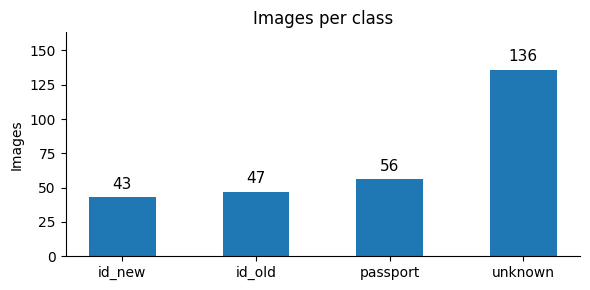


⚠️  Imbalance ratio: 3.2x — consider collecting more images for 'id_new'
   The split will still be stratified, but the minority class will have very few val/test samples.


In [88]:
label_names = {v: k for k, v in config.CLASSES.items()}
counts = {name: all_labels.count(label) for label, name in label_names.items()}
total  = len(all_labels)

print("Class distribution:")
for name, count in counts.items():
    pct   = count / total * 100
    print(f"  {name:10s}: {count:3d} images  ({pct:.1f}%)")

# Visual bar chart
fig, ax = plt.subplots(figsize=(6, 3))
bars    = ax.bar(counts.keys(), counts.values(), width=0.5)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=11)
ax.set_ylabel("Images")
ax.set_title("Images per class")
ax.set_ylim(0, max(counts.values()) * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Imbalance warning
min_count = min(counts.values())
max_count = max(counts.values())
ratio = max_count / min_count
if ratio > 1.5:
    print(f"\n⚠️  Imbalance ratio: {ratio:.1f}x — consider collecting more images for '{min(counts, key=counts.get)}'")
    print(    "   The split will still be stratified, but the minority class will have very few val/test samples.")
else:
    print(f"\n✅ Classes are fairly balanced (ratio: {ratio:.1f}x)")

In [89]:
imgs_trainval, imgs_test, lbls_trainval, lbls_test = train_test_split(
    all_images, all_labels,
    test_size=config.TEST_RATIO,
    stratify=all_labels,
    random_state=config.RANDOM_SEED
)

val_ratio_adjusted = config.VAL_RATIO / (1 - config.TEST_RATIO)

imgs_train, imgs_val, lbls_train, lbls_val = train_test_split(
    imgs_trainval, lbls_trainval,
    test_size=val_ratio_adjusted,
    stratify=lbls_trainval,
    random_state=config.RANDOM_SEED
)

print(f"Split summary (total: {len(all_images)} images):")
print(f"  Train : {len(imgs_train):3d} images  ({len(imgs_train)/len(all_images)*100:.1f}%)")
print(f"  Val   : {len(imgs_val):3d} images  ({len(imgs_val)/len(all_images)*100:.1f}%)")
print(f"  Test  : {len(imgs_test):3d} images  ({len(imgs_test)/len(all_images)*100:.1f}%)")

Split summary (total: 282 images):
  Train : 196 images  (69.5%)
  Val   :  43 images  (15.2%)
  Test  :  43 images  (15.2%)


In [90]:
def class_distribution(labels: list, label_names: dict) -> dict:
    return {label_names[l]: labels.count(l) for l in sorted(label_names)}

splits = {
    "full" : all_labels,
    "train": lbls_train,
    "val"  : lbls_val,
    "test" : lbls_test,
}

print(f"{'Split':<8} {'Total':>6}  ", end="")
for name in config.CLASSES:
    print(f"  {name:>10}", end="")
print()
print("-" * 52)

for split_name, labels in splits.items():
    dist  = class_distribution(labels, label_names)
    total = len(labels)
    print(f"{split_name:<8} {total:>6}  ", end="")
    for name in config.CLASSES:
        count = dist[name]
        pct   = count / total * 100
        print(f"  {count:3d} ({pct:4.1f}%)", end="")
    print()

Split     Total        id_new      id_old    passport     unknown
----------------------------------------------------
full        282     43 (15.2%)   47 (16.7%)   56 (19.9%)  136 (48.2%)
train       196     30 (15.3%)   33 (16.8%)   39 (19.9%)   94 (48.0%)
val          43      6 (14.0%)    7 (16.3%)    9 (20.9%)   21 (48.8%)
test         43      7 (16.3%)    7 (16.3%)    8 (18.6%)   21 (48.8%)


In [91]:
def copy_split(
    images: list[Path],
    labels: list[int],
    dest_root: Path,
    label_names: dict,
    dry_run: bool = True
):
    """Copies images into dest_root/class_name/ preserving folder structure."""
    # Create class subdirectories
    for name in label_names.values():
        (dest_root / name).mkdir(parents=True, exist_ok=True)

    for img_path, label in zip(images, labels):
        class_name = label_names[label]
        dest       = dest_root / class_name / img_path.name
        if dry_run:
            print(f"  [DRY RUN] {img_path.name} → {dest_root.name}/{class_name}/")
        else:
            shutil.copy2(img_path, dest)

# ── DRY RUN first ───────────────────────────────────────────────────
print("DRY RUN — showing first 5 files per split\n")
for split_name, (imgs, lbls, dest) in {
    "train": (imgs_train, lbls_train, config.TRAIN_DIR),
    "val"  : (imgs_val,   lbls_val,   config.VAL_DIR),
    "test" : (imgs_test,  lbls_test,  config.TEST_DIR),
}.items():
    print(f"--- {split_name.upper()} ({len(imgs)} files) ---")
    copy_split(imgs[:5], lbls[:5], dest, label_names, dry_run=True)
    print()

DRY RUN — showing first 5 files per split

--- TRAIN (196 files) ---
  [DRY RUN] unknown_105.jpg → train/unknown/
  [DRY RUN] id_new_5.jpg → train/id_new/
  [DRY RUN] unknown_75.jpg → train/unknown/
  [DRY RUN] unknown_43.jpg → train/unknown/
  [DRY RUN] passport_19.jpg → train/passport/

--- VAL (43 files) ---
  [DRY RUN] passport_10.jpg → val/passport/
  [DRY RUN] passport_39.jpg → val/passport/
  [DRY RUN] passport_17.jpg → val/passport/
  [DRY RUN] id_old_6.jpg → val/id_old/
  [DRY RUN] unknown_63.jpg → val/unknown/

--- TEST (43 files) ---
  [DRY RUN] id_new_27.jpg → test/id_new/
  [DRY RUN] unknown_18.jpg → test/unknown/
  [DRY RUN] unknown_36.jpg → test/unknown/
  [DRY RUN] id_old_21.jpg → test/id_old/
  [DRY RUN] unknown_107.jpg → test/unknown/



In [92]:
for split_name, (imgs, lbls, dest) in {
    "train": (imgs_train, lbls_train, config.TRAIN_DIR),
    "val"  : (imgs_val,   lbls_val,   config.VAL_DIR),
    "test" : (imgs_test,  lbls_test,  config.TEST_DIR),
}.items():
    copy_split(imgs, lbls, dest, label_names, dry_run=False)
    print(f"{split_name}: {len(imgs)} files copied → {dest}")

print("\nAll splits complete.")

train: 196 files copied → D:\Aprender\Projects\ecuadorian-id-classifier\data\train
val: 43 files copied → D:\Aprender\Projects\ecuadorian-id-classifier\data\val
test: 43 files copied → D:\Aprender\Projects\ecuadorian-id-classifier\data\test

All splits complete.


In [93]:
print("Final dataset structure:\n")
for split_name, split_dir in [("train", config.TRAIN_DIR), ("val", config.VAL_DIR), ("test", config.TEST_DIR)]:
    split_total = 0
    print(f"data/{split_name}/")
    for class_name in config.CLASSES:
        class_dir = split_dir / class_name
        if class_dir.exists():
            n = len(list(class_dir.glob("*.jpg")))
            split_total += n
            print(f"  └── {class_name:10s}: {n:3d} images")
    print(f"  Total: {split_total}\n")

Final dataset structure:

data/train/
  └── id_new    :  30 images
  └── id_old    :  33 images
  └── passport  :  39 images
  └── unknown   :  94 images
  Total: 196

data/val/
  └── id_new    :   6 images
  └── id_old    :   7 images
  └── passport  :   9 images
  └── unknown   :  21 images
  Total: 43

data/test/
  └── id_new    :   7 images
  └── id_old    :   7 images
  └── passport  :   8 images
  └── unknown   :  21 images
  Total: 43



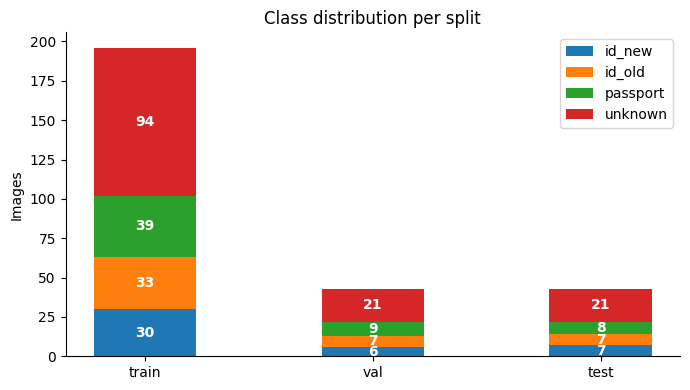

In [94]:
# Visual stacked bar — class distribution across splits
split_data = {
    "train": lbls_train,
    "val"  : lbls_val,
    "test" : lbls_test,
}
fig, ax    = plt.subplots(figsize=(7, 4))
bottoms    = {s: 0 for s in split_data}

for class_name, label in config.CLASSES.items():
    counts_per_split = [split_data[s].count(label) for s in split_data]
    bars = ax.bar(
        split_data.keys(), counts_per_split,
        bottom=[bottoms[s] for s in split_data],
        label=class_name, width=0.45
    )
    for bar, count in zip(bars, counts_per_split):
        if count > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                str(count), ha="center", va="center", fontsize=10, color="white", fontweight="bold"
            )
    for s, c in zip(split_data, counts_per_split):
        bottoms[s] += c

ax.set_ylabel("Images")
ax.set_title("Class distribution per split")
ax.legend(loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()